In [6]:
!pip install underthesea

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from underthesea import word_tokenize
import re

df = pd.read_csv('NPLpro.csv')
print(df.head())

                       comment label  rate Unnamed: 3
0               Áo bao đẹp ạ!!   POS     5        NaN
1                  Tuyệt vời !   POS     5        NaN
2   2day ao khong giong trong.   NEG     1        NaN
3  Mùi thơm,bôi lên da mềm da.   POS     5        NaN
4            Vải đẹp, dày dặn.   POS     5        NaN


In [14]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = word_tokenize(text, format="text")
    return text

df['comment_clean'] = df['comment'].apply(clean_text)
print(df[['comment', 'comment_clean']].head())

                       comment               comment_clean
0               Áo bao đẹp ạ!!                áo bao đẹp ạ
1                  Tuyệt vời !                   tuyệt_vời
2   2day ao khong giong trong.  2 day ao khong_giong trong
3  Mùi thơm,bôi lên da mềm da.   mùi thơmbôi lên da mềm da
4            Vải đẹp, dày dặn.             vải đẹp dày dặn


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11592\1677917255.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


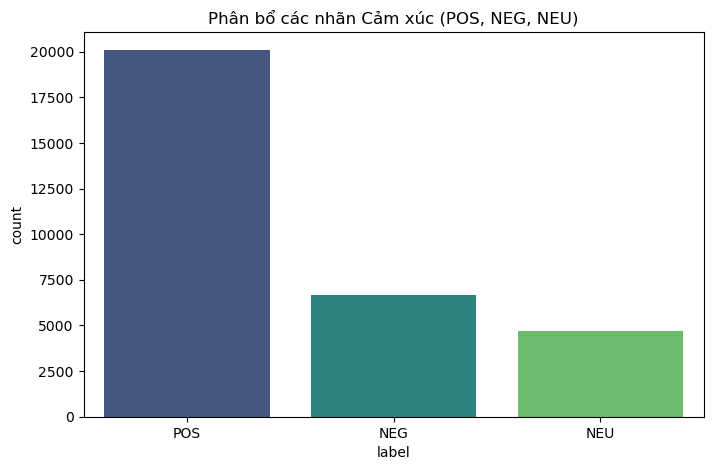

label
NEG    1.470835
NEU    3.000000
POS    4.661225
Name: rate, dtype: float64


In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Phân bổ các nhãn Cảm xúc (POS, NEG, NEU)')
plt.show()


print(df.groupby('label')['rate'].mean())

Text(0.5, 1.0, 'Phân bố tỷ lệ theo nhãn')

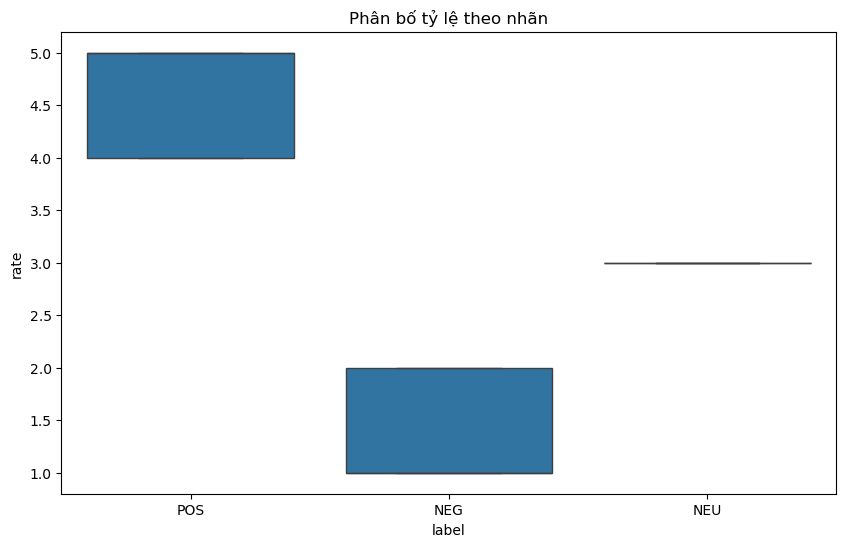

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='label', y='rate')
plt.title('Phân bố tỷ lệ theo nhãn')


In [24]:
from collections import Counter

def get_top_words(label, top_n=20):
    words = " ".join(df[df['label'] == label]['comment_clean']).split()
    return Counter(words).most_common(top_n)

pos_words = get_top_words('POS')
neg_words = get_top_words('NEG')

print("\nTop POS words:", pos_words)
print("Top NEG words:", neg_words)


Top POS words: [('rất', 11343), ('sản_phẩm', 7622), ('đẹp', 7398), ('shop', 5186), ('hàng', 4972), ('chất_lượng', 4951), ('tuyệt_vời', 3739), ('giao', 3450), ('và', 3433), ('đóng_gói', 3134), ('nhanh', 2950), ('tốt', 2906), ('chắc_chắn', 2850), ('tiền', 2623), ('áo', 2333), ('đáng', 2332), ('thời_gian', 2220), ('phục_vụ', 2212), ('vải', 1560), ('lắm', 1395)]
Top NEG words: [('hàng', 1069), ('áo', 985), ('shop', 950), ('ko', 922), ('rất', 915), ('giao', 905), ('k', 857), ('không', 853), ('sản_phẩm', 836), ('màu', 776), ('kém', 681), ('chất_lượng', 645), ('vải', 633), ('như', 602), ('nhưng', 600), ('quá', 592), ('bị', 582), ('thì', 573), ('mà', 569), ('mua', 544)]


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


df['comment_clean'] = df['comment'].apply(clean_text)


X_train, X_test, y_train, y_test = train_test_split(
    df['comment_clean'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)


vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_tfidf, y_train)


y_pred = model.predict(X_test_tfidf)
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

         NEG       0.64      0.71      0.67      1334
         NEU       0.32      0.48      0.38       939
         POS       0.93      0.78      0.85      4019

    accuracy                           0.72      6292
   macro avg       0.63      0.66      0.63      6292
weighted avg       0.78      0.72      0.74      6292



Text(95.72222222222221, 0.5, 'Actual')

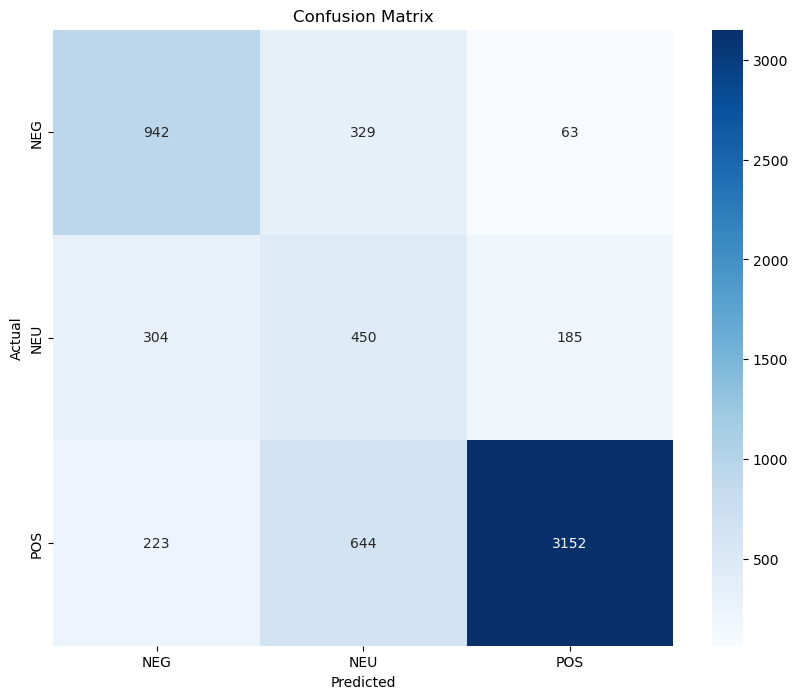

In [32]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

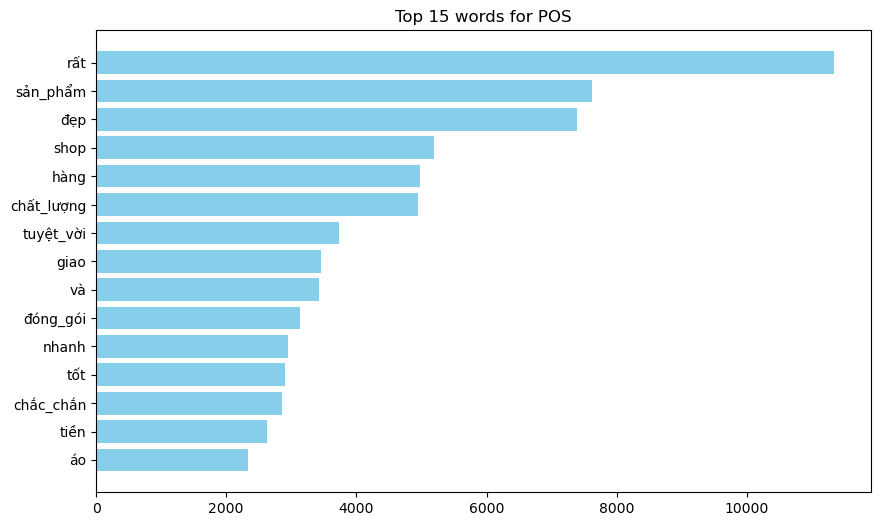

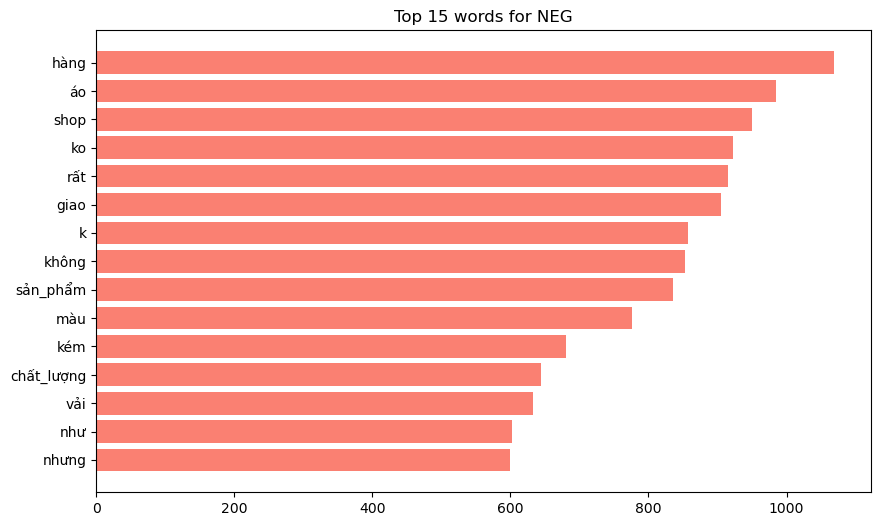

In [34]:
import numpy as np

def plot_top_n_words(label, n=15):
    subset = df[df['label'] == label]['comment_clean']
    words = " ".join(subset).split()
    word_counts = Counter(words).most_common(n)
    words_df = pd.DataFrame(word_counts, columns=['word', 'count']).sort_values('count', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(words_df['word'], words_df['count'], color='skyblue' if label == 'POS' else 'salmon')
    plt.title(f'Top {n} words for {label}')
    plt.savefig(f'top_words_{label}.png')

plot_top_n_words('POS')
plot_top_n_words('NEG')

In [42]:
test_comments = [
    "Sản phẩm dùng rất tốt, đóng gói cẩn thận",
    "Áo quá mỏng, đường may cẩu thả, thất vọng",
    "Giao hàng nhanh nhưng chất lượng bình thường",
    "Shop phục vụ rất nhiệt tình, 5 sao nhé",
    "Lừa đảo, đừng mua mọi người ơi",
    "Chất lượng sp quá tệ, phí tiền vãi",
    "Ko giống hình, chánnnnnn",
    "Hàng về bị rách một lỗ to, nhắn tin shop không thèm rep"
]

cleaned_samples = [clean_text(c) for c in test_comments]

vectorized_samples = vectorizer.transform(cleaned_samples)

predictions = model.predict(vectorized_samples)

print("\n--- KẾT QUẢ TEST THỰC TẾ ---")
for comment, label in zip(test_comments, predictions):
    print(f"Bình luận: {comment}")
    print(f"==> Dự đoán: {label}\n")


--- KẾT QUẢ TEST THỰC TẾ ---
Bình luận: Sản phẩm dùng rất tốt, đóng gói cẩn thận
==> Dự đoán: POS

Bình luận: Áo quá mỏng, đường may cẩu thả, thất vọng
==> Dự đoán: NEG

Bình luận: Giao hàng nhanh nhưng chất lượng bình thường
==> Dự đoán: NEU

Bình luận: Shop phục vụ rất nhiệt tình, 5 sao nhé
==> Dự đoán: POS

Bình luận: Lừa đảo, đừng mua mọi người ơi
==> Dự đoán: NEG

Bình luận: Chất lượng sp quá tệ, phí tiền vãi
==> Dự đoán: NEU

Bình luận: Ko giống hình, chánnnnnn
==> Dự đoán: NEG

Bình luận: Hàng về bị rách một lỗ to, nhắn tin shop không thèm rep
==> Dự đoán: NEG

